In [1]:
# adapted from https://github.com/DifferentiableUniverseInitiative/Baryonator/blob/main/notebooks/EGD_demo_on_CAMELS.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

import jax
import jax.lax as lax 
import jax.numpy as jnp
import optax

from jaxpm import camels, objectives, egd, training
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, gaussian_kernel

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [4]:
p_spectrum = lambda delta: power_spectrum(
    compensate_cic(delta),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

x_spectrum = lambda delta_1, delta_2: cross_correlation_coefficients(
    compensate_cic(delta_1),
    compensate_cic(delta_2),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

# Loading the CAMELS snapshot

In [5]:
# mesh_per_dim = 64
mesh_per_dim = 128
mesh_shape = [mesh_per_dim] * 3

parts_per_dim = mesh_shape[0]
# parts_per_dim = None

CODE = "SIMBA"

CV = "CV_0"
# CV = "CV_1"

CAMELS = "/pscratch/sd/a/athomsen/flatiron/CAMELS"

# initial conditions
dmo_dict = camels.load_CV_snapshots(
    CV,
    mesh_per_dim,
    parts_per_dim=parts_per_dim,
    i_snapshots=0,
    CAMELS=CAMELS,
    CODE=CODE,
    return_hydro=False,
)

# reference
hydro_dict = camels.load_CV_snapshots(
    CV,
    mesh_per_dim,
    parts_per_dim=parts_per_dim,
    i_snapshots=None,
    CAMELS=CAMELS,
    CODE=CODE,
    return_hydro=True,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA_DM/CV/CV_0/parts=128,mesh=128,i=[0].h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=128,mesh=128.h5


In [6]:
cosmo = hydro_dict["cosmo"]
scales = hydro_dict["scales"]

Omega_m = cosmo.Omega_m
Omega_b = cosmo.Omega_b
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

# initial
init_pos_dm = dmo_dict["dm_poss"]
init_vel_dm = dmo_dict["dm_vels"]
init_scale = dmo_dict["scales"]

# reference
i_ref = -1
ref_pos_dm = hydro_dict["dm_poss"][i_ref]
ref_pos_gas = hydro_dict["gas_poss"][i_ref]
ref_scale = hydro_dict["scales"][i_ref]

ref_rho_dm = cic_paint(jnp.zeros(mesh_shape), ref_pos_dm, weight=dm_mass)
ref_rho_gas = cic_paint(jnp.zeros(mesh_shape), ref_pos_gas, weight=gas_mass)
ref_rho_tot = ref_rho_dm + ref_rho_gas

ref_delta_gas = ref_rho_gas / ref_rho_gas.mean() - 1
ref_delta_tot = ref_rho_tot / ref_rho_tot.mean() - 1

k, pk_ref_gas = p_spectrum(ref_delta_gas)
_, pk_ref_tot = p_spectrum(ref_delta_tot)

solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)

In [7]:
y0 = (init_pos_dm, init_vel_dm)
t0 = init_scale
tsave = jnp.array([ref_scale])
pm_res = solve_ode(
    y0, t0, tsave, gravity_model=None, pressure_model=None, training=False, nt=2, tstep=scales
)
pm_dm_pos, pm_dm_vels = pm_res

# tot = dm
pm_rho_tot = cic_paint(jnp.zeros(mesh_shape), pm_dm_pos, weight=1)
pm_delta_tot = pm_rho_tot/pm_rho_tot.mean() - 1

_, pk_pm_tot = p_spectrum(pm_delta_tot)
_, xpk_pm_tot = x_spectrum(pm_delta_tot, ref_delta_tot)

Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter only
dark matter only
dark matter only


# EGD

In [8]:
inds = jax.random.permutation(jax.random.PRNGKey(42), jnp.arange(0,len(pm_dm_pos)-1))
split = int(Omega_b / Omega_m * len(pm_dm_pos))
egd_gas_pos = pm_dm_pos[inds[:split]]
egd_dm_pos = pm_dm_pos[inds[split:]]

egd_rho_dm = cic_paint(jnp.zeros(mesh_shape), egd_dm_pos)

In [9]:
@jax.jit
def loss_fn(params):
    egdized_gas_pos = egd_gas_pos + egd.egd_correction(params, pm_delta_tot, egd_gas_pos, mesh_shape)
    
    # Add the gas that we have moved to the dm that stayed where it was
    egd_rho_gas = cic_paint(jnp.zeros(mesh_shape), egdized_gas_pos)
    egd_rho_tot = egd_rho_dm + egd_rho_gas

    delta_gas = egd_rho_gas / egd_rho_gas.mean() - 1
    k, pk_gas = p_spectrum(delta_gas)
    inds = k < 4.0
    loss = jnp.sum(((pk_gas/pk_ref_gas - 1))[inds]**2, axis=-1)

    return loss
    
    # delta_tot = egd_rho_tot / egd_rho_tot.mean() - 1
    
    # # Compute the PS of everybody
    # k, pk = p_spectrum(delta_tot)
    
    # # Some weighting function of the pk, following Biwei's strategy
    # inds = k < 10.
    # loss = jnp.sum(((pk/pk_hydro -1))[inds]**2,axis=-1)
    
    # # loss = jnp.sum((delta-tot_delta_hydro)**2)
    
    # return loss



In [10]:
total_steps = 10_000

learning_rate = optax.cosine_decay_schedule(
    init_value=1e-3,
    decay_steps=total_steps, 
    alpha=0.0,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate)
)

In [11]:
@jax.jit
def update(params, opt_state):
    return egd.update(params, optimizer, opt_state, loss_fn)

In [12]:
params = [0.5, 1.4, 0.4] # amplitude, scale, gamma
opt_state = optimizer.init(params)
losses = []

2025-08-29 09:26:51.110523: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %scatter.0 = f32[65]{0} scatter(%broadcast.116, %constant.191, %constant.193), update_window_dims={1}, inserted_window_dims={}, scatter_dims_to_operand_dims={0}, index_vector_dim=1, to_apply=%region_5.394, metadata={op_name="jit(update)/jvp(jit(loss_fn))/scatter-add" source_file="/global/u2/a/athomsen/flatiron/JaxPM/jaxpm/utils.py" source_line=71}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-08-29 09:26:55.724147: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 5.613776733s

[Array(0.00070979, dtype=float32), Array(0.56578654, dtype=float32), Array(1.8655127, dtype=float32)]


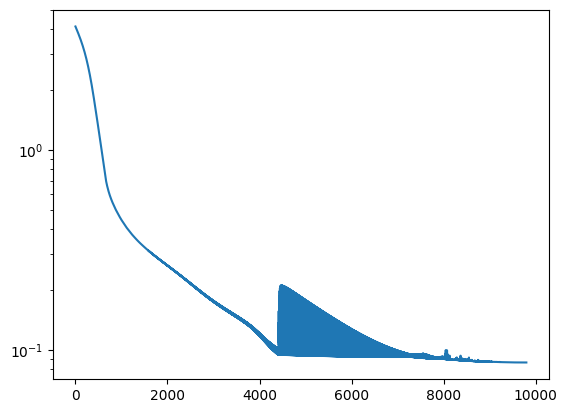

In [13]:
for step in tqdm(range(total_steps)):
  l, params, opt_state = update(params, opt_state)
  losses.append(l)

fig, ax = plt.subplots()
ax.plot(losses[200:])
ax.set(yscale="log")
print(params)

In [14]:
egd_rho_gas = cic_paint(jnp.zeros(mesh_shape), egd_gas_pos + egd.egd_correction(params, pm_delta_tot, egd_gas_pos, mesh_shape))
egd_rho_tot = egd_rho_dm + egd_rho_gas

egd_delta_gas = egd_rho_gas/egd_rho_gas.mean() - 1
egd_delta_tot = egd_rho_tot/egd_rho_tot.mean() - 1

_, pk_egd_gas = p_spectrum(egd_delta_gas)
_, xpk_egd_gas = x_spectrum(egd_delta_gas, ref_delta_gas)

[Text(0.5, 1.0, 'EGD Gas')]

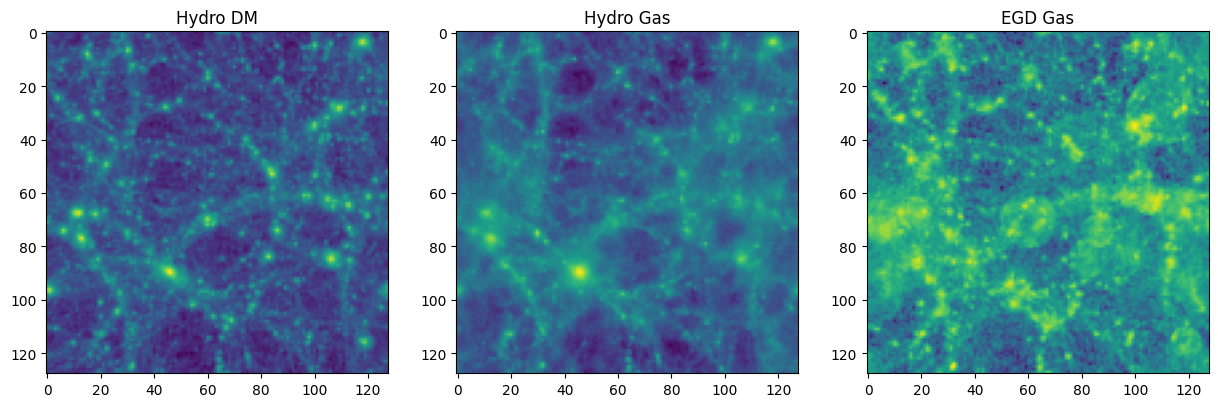

In [15]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

ax[0].imshow(ref_rho_dm.sum(axis=0), norm="log")
ax[0].set(title="Hydro DM")

ax[1].imshow(ref_rho_gas.sum(axis=0), norm="log")
ax[1].set(title="Hydro Gas")

ax[2].imshow(egd_rho_gas.sum(axis=0), norm="log")
ax[2].set(title="EGD Gas")

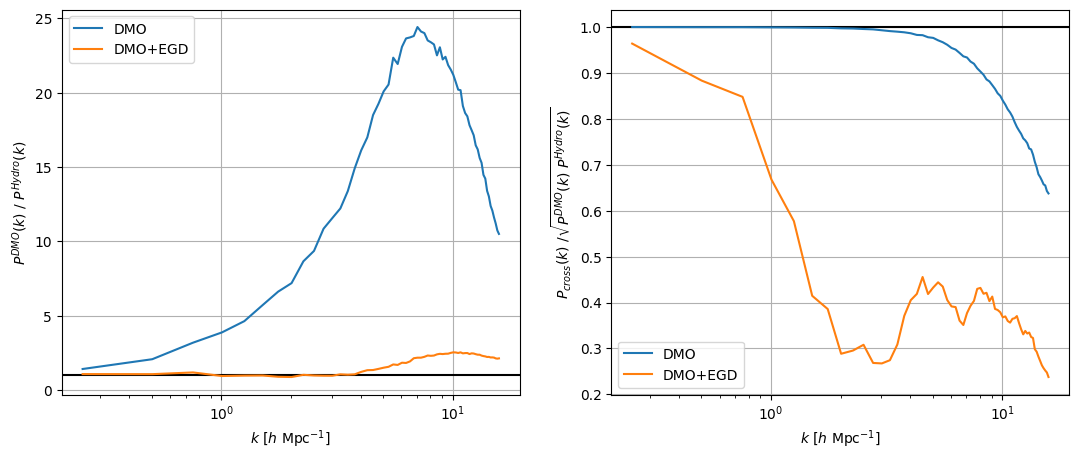

In [16]:
fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_pm_tot/pk_ref_gas), label='DMO')   
ax[0].semilogx(k, (pk_egd_gas/pk_ref_gas), label='DMO+EGD')   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    # xlim=(0.1, 15),
    # ylim=(0., 1.5),
)
ax[0].grid(True)
ax[0].legend()

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk_pm_tot/(jnp.sqrt(pk_pm_tot)*jnp.sqrt(pk_ref_tot)), label='DMO')
ax[1].semilogx(k, xpk_egd_gas/(jnp.sqrt(pk_egd_gas)*jnp.sqrt(pk_ref_gas)), label='DMO+EGD')
ax[1].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    # xlim=(0.1, 15),
    # ylim=(0.95, 1.05),
)
ax[1].grid()
ax[1].legend()